# DSCI 521 Final Projec: Data Engineering for Modeling

In this notebook we will be carrying out the necessary feature and data engineering to prepare the data for our predictive modeling phase.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

## Data Import

In [ ]:
data_path = "/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/shot_rally.csv"

In [ ]:
df = pd.read_csv(data_path)

In [ ]:
df.head(10)

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
0,289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,...,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over,NaN,NaN
1,289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,...,P182,8.71,-20.58,6.05,8.08,Unforced Error,Winner,Game Over,HB,NaN
2,289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,...,P184,17.53,20.76,8.71,-20.58,Unforced Error,Extend Rally,Game Over,tsDrv,HB
3,289844,M99,G178,R7807,65,4,T135,T136,T135,S72056,...,P181,7.42,-20.94,17.53,20.76,Unforced Error,Start Rally,Game Over,R,tsDrv
4,289843,M99,G178,R7806,64,4,T135,T136,T135,S72055,...,P184,11.56,7.72,NaN,NaN,Unforced Error,Unforced Error,Point,NaN,NaN
5,289842,M99,G178,R7806,64,4,T135,T136,T135,S72054,...,P181,14.96,-19.84,11.56,7.72,Unforced Error,Winner,Point,HB,NaN
6,289841,M99,G178,R7806,64,4,T135,T136,T135,S72053,...,P183,2.74,20.58,14.96,-19.84,Unforced Error,Extend Rally,Point,tsDrv,HB
7,289840,M99,G178,R7806,64,4,T135,T136,T135,S72052,...,P181,15.60,-21.04,2.74,20.58,Unforced Error,Start Rally,Point,R,tsDrv
8,289839,M99,G178,R7805,63,8,T135,T136,T135,S72051,...,P183,3.38,7.90,NaN,NaN,Unforced Error,Unforced Error,Point,NaN,NaN
9,289838,M99,G178,R7805,63,8,T135,T136,T135,S72050,...,P182,8.62,-20.30,3.38,7.90,Unforced Error,Extend Rally,Point,HB,NaN


## Data and Feature Engineering

In [ ]:
# First we want to order the data frame based on game_id, match_id and rally_id
sorted_df = df.sort_values(['match_id','game_id','rally_id', 'rally_nbr','shot_nbr'], ascending=True)
sorted_df.head(10)

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
304429,290875,M10,G18,R814,1,5,T13,T14,T14,S8558,...,P23,12.11,-25.83,1.33,26.35,Other,Start Rally,Side Out,R,tsDrp
304428,290876,M10,G18,R814,1,5,T13,T14,T14,S8559,...,P25,1.33,26.35,12.91,-25.24,Other,Extend Rally,Side Out,tsDrp,HB
304427,290877,M10,G18,R814,1,5,T13,T14,T14,S8560,...,P23,12.91,-25.24,18.87,8.72,Other,Extend Rally,Side Out,HB,HB
304426,290878,M10,G18,R814,1,5,T13,T14,T14,S8561,...,P26,18.87,8.72,12.37,-17.52,Other,Extend Rally,Side Out,HB,NaN
304425,290879,M10,G18,R814,1,5,T13,T14,T14,S8562,...,P24,12.37,-17.52,NaN,NaN,Other,Other,Side Out,NaN,NaN
304424,290960,M10,G18,R815,2,3,T14,T13,T13,S8563,...,P25,15.45,-26.79,3.88,26.41,Unforced Error,Start Rally,Next Server,R,tsDrp
304423,290961,M10,G18,R815,2,3,T14,T13,T13,S8564,...,P23,3.88,26.41,15.99,-26.35,Unforced Error,Extend Rally,Next Server,tsDrp,NaN
304422,290962,M10,G18,R815,2,3,T14,T13,T13,S8565,...,P25,15.99,-26.35,NaN,NaN,Unforced Error,Unforced Error,Next Server,NaN,NaN
304421,291049,M10,G18,R816,3,10,T14,T13,T13,S8566,...,P26,4.21,-26.06,16.87,26.27,Winner,Start Rally,Side Out,R,tsDrp
304420,291050,M10,G18,R816,3,10,T14,T13,T13,S8567,...,P24,16.87,26.27,-0.88,-22.27,Winner,Extend Rally,Side Out,tsDrp,D


### Removing Columns from the data

In [ ]:
cols_to_drop = ['ending_type', 'shot_outcome', 'rally_outcome','next_shot_type', 'next_2-shot_type']
sorted_df = sorted_df.drop(cols_to_drop, axis=1)

### Adding Features to the Data Frame

First we are going to conert the scale of our shot locations as we wish for it to be standardized

In [ ]:
def standardize_court_loc(df):
  df = df.copy()
  df['loc_x'] = df['loc_x'] / 20
  df['loc_y'] = df['loc_y'] / 20
  df['next_loc_x'] = df['next_loc_x'] / 20
  df['next_loc_y'] = df['next_loc_y'] / 20
  return df

In [ ]:
sorted_df = standardize_court_loc(sorted_df)

#### Feature 1: Change in X direction (Delta X)

In [ ]:
def delta_x_loc(df):
    df = df.copy()
    df['delta_x_loc'] = df['next_loc_x'] - df['loc_x']
    return df

In [ ]:
sorted_df = delta_x_loc(sorted_df)

#### Feature 2: Change in Y direction (Delta Y)

In [ ]:
def delta_y_loc(df):
    df = df.copy()
    df['delta_y_loc'] = df['next_loc_y'] - df['loc_y']
    return df

In [ ]:
sorted_df = delta_y_loc(sorted_df)

#### Feature 3: Shot Distance

In [ ]:
def add_shot_distance(df):
    df = df.copy()

    # 1. Reuse or calculate the differences
    dx = df['delta_x_loc']
    dy = df['delta_y_loc']

    # 2. Calculate Euclidean Distance
    # np.hypot(dx, dy) is equivalent to sqrt(dx**2 + dy**2)
    df['shot_distance'] = np.hypot(dx, dy)

    return df

In [ ]:
sorted_df = add_shot_distance(sorted_df)

In [ ]:
#sorted_df['shot_distance'] = np.sqrt((sorted_df['loc_x'] - sorted_df['next_loc_x'])**2 + (sorted_df['loc_y'] - sorted_df['next_loc_y'])**2)

#### Feature 4: Shot Angle (in Radians)

In [ ]:
def add_shot_angle(df):
    """
    Calculates the angle of the shot in radians using arctan2.
    Handles the trajectory from current location to next location.
    """
    df = df.copy()

    # 1. Calculate the coordinate deltas
    dy = df['next_loc_y'] - df['loc_y']
    dx = df['next_loc_x'] - df['loc_x']

    # 2. Use arctan2 (y, x) for quadrant-aware angles (-pi to pi)
    # This correctly identifies shots moving 'backward' or 'sideways'
    df['shot_angle'] = np.arctan2(dy, dx)

    return df

In [ ]:
sorted_df = add_shot_angle(sorted_df)

#### Feature 5: Distance to the Kitchen Line

In [ ]:
def add_kitchen_distance(df):
    df = df.copy()

    # 1. Identify which side of the net the ball is on (7 or -7)
    # 2. Subtract the ball's y-position from that line
    # 3. Use abs() to ensure the distance is always positive
    df['dist_to_kitchen'] = df['loc_y'].apply(lambda y: abs(y - 7) if y > 0 else abs(y + (-7)))

    # Optional: If the ball is INSIDE the kitchen, set distance to 0
    # (i.e., if |y| < 7, the ball is in the kitchen)
    df.loc[df['loc_y'].abs() < 7, 'dist_to_kitchen'] = 0

    return df

In [ ]:
sorted_df = add_kitchen_distance(sorted_df)

#### Feature 6: Target Variable (Point won)

In [ ]:
# now to create the indicator variable for point won
# This will be quite simple to do as it will be the indication if the serving team is the team that
# won the point

# We also chose to create a defensive point indicator as a way to help people playing the return of serve
# So there will be two different models at play here!

sorted_df['srv_point_won'] = (sorted_df['srv_team_id'] == sorted_df['w_team_id']).astype(int)
#sorted_df['def_point_won'] = (sorted_df['srv_team_id'] != sorted_df['w_team_id']).astype(int)

In [ ]:
sorted_df['srv_point_won'].value_counts()

,count
srv_point_won,
0,169256
1,135174


#### Adding Game Level to the data

This will help us differentiate different levels of play as we have seen in eda that different skill levels have different play styles

In [ ]:
game_df = pd.read_csv('/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/raw/game.csv')

In [ ]:
game_df.head()

,game_id,match_id,game_nbr,score_w,score_l,w_team_id,l_team_id,skill_lvl,scoring_type,ball_type,dt_played
0,G347,M219,1,12,10,T311,T310,Pro,STANDARD_DOUBLES,D40,2022-10-25
1,G481,M317,1,5,5,T391,T390,4.0,STANDARD_DOUBLES,U,2023-10-01
2,G361,M227,1,15,9,T159,T321,3.5,STANDARD_DOUBLES,FX40,2023-10-21
3,G107,M54,1,11,4,T78,T82,4.5,STANDARD_DOUBLES,U,2023-02-25
4,G104,M52,1,11,5,T78,T79,4.5,STANDARD_DOUBLES,U,2023-02-25


In [ ]:
new_df = pd.merge(sorted_df, game_df[['game_id', 'skill_lvl']], on='game_id',
                 how='left')

In [ ]:
new_df.head()

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,loc_y,next_loc_x,next_loc_y,delta_x_loc,delta_y_loc,shot_distance,shot_angle,dist_to_kitchen,srv_point_won,skill_lvl
0,290875,M10,G18,R814,1,5,T13,T14,T14,S8558,...,-1.2915,0.0665,1.3175,-0.539,2.6090,2.664095,1.774523,0.0,0,Pro
1,290876,M10,G18,R814,1,5,T13,T14,T14,S8559,...,1.3175,0.6455,-1.2620,0.579,-2.5795,2.643683,-1.349994,0.0,0,Pro
2,290877,M10,G18,R814,1,5,T13,T14,T14,S8560,...,-1.2620,0.9435,0.4360,0.298,1.6980,1.723951,1.397065,0.0,0,Pro
3,290878,M10,G18,R814,1,5,T13,T14,T14,S8561,...,0.4360,0.6185,-0.8760,-0.325,-1.3120,1.351654,-1.813622,0.0,0,Pro
4,290879,M10,G18,R814,1,5,T13,T14,T14,S8562,...,-0.8760,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,Pro


### Editing Categorical Variables

#### Creating Bins for Skill Level

We noticed from the data that there are similarities in play style based on various skill levels. We decided to make the analysis more concise that we will create bins to minimize the number of skill level categories.

For simplicity we will be creating Beginner, Intermediate, and Advanced bins which can be further dowstream one hot encoded to

In [ ]:
new_df['skill_lvl'].unique()

array(['Pro', '5.0', '4.0', '3.5', '3.0', '4.5', 'Senior Pro', '2.5',
       '5.5'], dtype=object)

In [ ]:
new_df['skill_lvl'].value_counts()

,count
skill_lvl,
4.0,95331
Pro,80377
5.0,59897
4.5,39617
3.5,16330
5.5,7350
3.0,3547
Senior Pro,1015
2.5,966


In [ ]:
skill_lvl_map = {
    'Pro' : 'Pro',
    'Senior Pro' : 'Pro',
    '5.5' : 'Pro',
    '5.0' : 'Advanced',
    '4.5' : 'Advanced',
    '4.0': 'Intermediate',
    '3.5': 'Intermediate',
    '3.0': 'Beginner',
    '2.5': 'Beginner'
}

new_df['skill_lvl_bins'] = new_df['skill_lvl'].map(skill_lvl_map)

In [ ]:
new_df = pd.get_dummies(new_df, columns=['skill_lvl_bins'], prefix='skill')

In [ ]:
skill_cols = ['skill_Advanced', 'skill_Beginner', 'skill_Intermediate', 'skill_Pro']
new_df[skill_cols] = new_df[skill_cols].astype(int)

#### Who is hitting the Shot?

This will help us further understand the sequence of the shots in the data it will be added for not in case the model needs it

In [ ]:
def add_team_hitting_column(df):
    # .copy() prevents 'SettingWithCopy' warnings if your df is a slice
    df = df.copy()

    # 1. Check if shot_nbr is odd:
    # (df['shot_nbr'] % 2) returns 1 for odd, 0 for even
    df['team_hitting'] = (df['shot_nbr'] % 2).astype(int)

    return df

In [ ]:
new_df = add_team_hitting_column(new_df)

### Filling In Null values within the Data

Null values within this data relates to the end of a rally, so they serve as an indicator. In the case of our model, these null values being present will only hurt the models performace thus leading us to find a better way to represent them.

#### Null numerical values

Initially we have decided to impute a large value such as (-999) in order to still capture the essence of the null value but also serve as an indicator that this provides no real value to our coordinate system. This proves to be damaging to the neural network so we will look for a better alternative.

It appears that the best option to solve this issue is to create a column that indicates wether or not a variable is missing from the data and then impute the mising value with a value of zero. This will help to maintain the integrity of the data but would also allow us

In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304430 entries, 0 to 304429
Data columns (total 29 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          304430 non-null  int64  
 1   match_id            304430 non-null  object 
 2   game_id             304430 non-null  object 
 3   rally_id            304430 non-null  object 
 4   rally_nbr           304430 non-null  int64  
 5   rally_len           304430 non-null  int64  
 6   srv_team_id         304430 non-null  object 
 7   rtrn_team_id        304430 non-null  object 
 8   w_team_id           304430 non-null  object 
 9   shot_id             304430 non-null  object 
 10  shot_nbr            304430 non-null  int64  
 11  shot_type           304430 non-null  object 
 12  player_id           304374 non-null  object 
 13  loc_x               304430 non-null  float64
 14  loc_y               304430 non-null  float64
 15  next_loc_x          292638 non-nul

In [ ]:
def fill_null_numerical_values(df, cols):
  for col in cols:
    new_column_name = col + '_missing'
    df[new_column_name] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(0)
  return df

In [ ]:
null_numerical_cols = ['next_loc_x', 'next_loc_y', 'delta_x_loc', 'delta_y_loc', 'shot_distance', 'shot_angle']
clean_mdl_data = fill_null_numerical_values(new_df, null_numerical_cols)

In [ ]:
clean_mdl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304430 entries, 0 to 304429
Data columns (total 35 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             304430 non-null  int64  
 1   match_id               304430 non-null  object 
 2   game_id                304430 non-null  object 
 3   rally_id               304430 non-null  object 
 4   rally_nbr              304430 non-null  int64  
 5   rally_len              304430 non-null  int64  
 6   srv_team_id            304430 non-null  object 
 7   rtrn_team_id           304430 non-null  object 
 8   w_team_id              304430 non-null  object 
 9   shot_id                304430 non-null  object 
 10  shot_nbr               304430 non-null  int64  
 11  shot_type              304430 non-null  object 
 12  player_id              304374 non-null  object 
 13  loc_x                  304430 non-null  float64
 14  loc_y                  304430 non-nu

In [ ]:
clean_mdl_data.head()

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,skill_Beginner,skill_Intermediate,skill_Pro,team_hitting,next_loc_x_missing,next_loc_y_missing,delta_x_loc_missing,delta_y_loc_missing,shot_distance_missing,shot_angle_missing
0,290875,M10,G18,R814,1,5,T13,T14,T14,S8558,...,0,0,1,1,0,0,0,0,0,0
1,290876,M10,G18,R814,1,5,T13,T14,T14,S8559,...,0,0,1,0,0,0,0,0,0,0
2,290877,M10,G18,R814,1,5,T13,T14,T14,S8560,...,0,0,1,1,0,0,0,0,0,0
3,290878,M10,G18,R814,1,5,T13,T14,T14,S8561,...,0,0,1,0,0,0,0,0,0,0
4,290879,M10,G18,R814,1,5,T13,T14,T14,S8562,...,0,0,1,1,1,1,1,1,1,1


#### Reduced Shot Mapping



In [ ]:
clean_mdl_data['shot_type'].value_counts()

,count
shot_type,
D,59533
HB,45135
SE,39906
R,38764
tzRep,35076
tzApp,25989
tsDrp,20062
tsDrv,15873
SP,14233


In [ ]:
shot_type_map = {
    'D' : 'Dink',
    'HB' : 'Volley',
    'SE' : 'Serve',
    'R' : 'Return',
    'tzRep' : 'Repel',
    'tzApp': 'tzApp',
    'tsDrp': 'Drop',
    'tsDrv': 'Drive',
    'SP': 'Speed Up',
    'Res': 'Reset',
    'U': 'U',
    'L': 'Lob',
    'tsLob': 'Lob',
    'E': 'Volley',
    'A': 'Speed Up',
    'O': 'O',
    'ball': 'ball'
}

clean_mdl_data['shot_type_bins'] = clean_mdl_data['shot_type'].map(shot_type_map)

In [ ]:
clean_mdl_data['shot_type_bins'].value_counts()

,count
shot_type_bins,
Dink,59533
Volley,45356
Serve,39906
Return,38764
Repel,35076
tzApp,25989
Drop,20062
Drive,15873
Speed Up,14367


#### Splitting Unknown Shot Types into know Categories

In [ ]:
tzApp_shots_df = clean_mdl_data[clean_mdl_data['shot_type'] == 'tzApp']


In [ ]:
import seaborn as sns

<Axes: xlabel='shot_distance', ylabel='Count'>

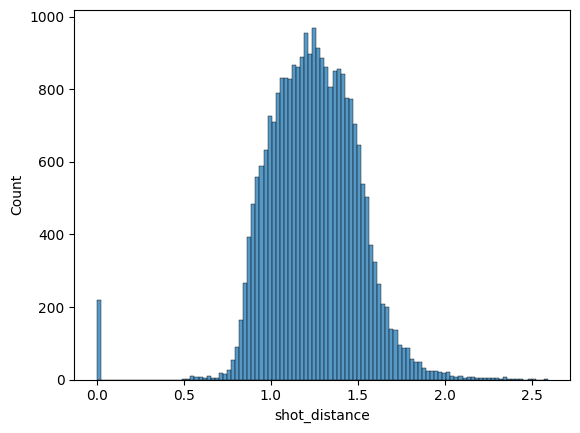

In [ ]:
sns.histplot(data=tzApp_shots_df, x='shot_distance')

<Axes: xlabel='next_loc_y', ylabel='Count'>

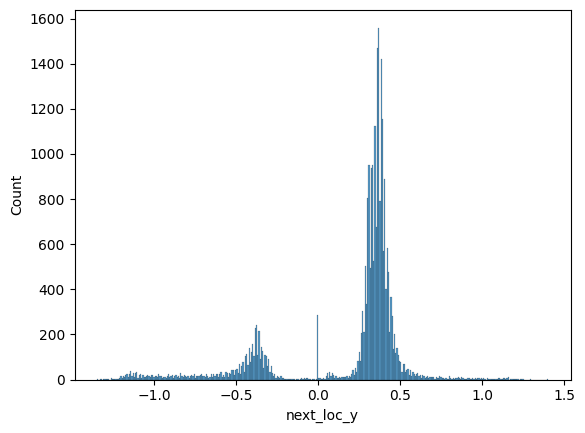

In [ ]:
sns.histplot(data=tzApp_shots_df, x='next_loc_y')

We want to further break down the number of shot types within the data so we want to break up the tzApp category into shot types of Drop, Reset or Lob as we determine these shots as the best ways for a player to approach the kitchen line by slowing down play. Initially we thought that hard encoding these categories was the way to go, but it seems that we will be missing a lot of information from the data by doing this approach

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

In [ ]:
# After first pass shot_nbr and next_loc_missing were most important features
features = ['loc_x', 'loc_y', 'next_loc_x', 'next_loc_y', 'delta_x_loc', 'delta_y_loc', 'shot_distance', 'dist_to_kitchen', 'shot_angle', 'skill_Advanced', 'skill_Beginner', 'skill_Intermediate', 'skill_Pro']

In [ ]:
# 2. Split into Training (Knowns) and Prediction (Unkown)
train_df = clean_mdl_data[~clean_mdl_data['shot_type_bins'].isin(['tzApp','U','O','ball'])]
predict_df = clean_mdl_data[clean_mdl_data['shot_type_bins'].isin(['tzApp','U','O','ball'])]

In [ ]:
train_df.head()

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,skill_Intermediate,skill_Pro,team_hitting,next_loc_x_missing,next_loc_y_missing,delta_x_loc_missing,delta_y_loc_missing,shot_distance_missing,shot_angle_missing,shot_type_bins
0,290875,M10,G18,R814,1,5,T13,T14,T14,S8558,...,0,1,1,0,0,0,0,0,0,Serve
1,290876,M10,G18,R814,1,5,T13,T14,T14,S8559,...,0,1,0,0,0,0,0,0,0,Return
2,290877,M10,G18,R814,1,5,T13,T14,T14,S8560,...,0,1,1,0,0,0,0,0,0,Drop
3,290878,M10,G18,R814,1,5,T13,T14,T14,S8561,...,0,1,0,0,0,0,0,0,0,Volley
4,290879,M10,G18,R814,1,5,T13,T14,T14,S8562,...,0,1,1,1,1,1,1,1,1,Volley


In [ ]:
train_df['shot_type_bins'].value_counts()

,count
shot_type_bins,
Dink,59533
Volley,45356
Serve,39906
Return,38764
Repel,35076
Drop,20062
Drive,15873
Speed Up,14367
Reset,3808


In [ ]:
# Change to a train test split and stratify the data (70, 20, 10) split for train, val, test
from sklearn.model_selection import train_test_split
X = train_df[features]
y = train_df['shot_type_bins']

# Splitting the data into Train, Validation and Test Sets
x_train_val, X_test, y_train_val, y_test = train_test_split(X, y, train_size = 0.80, random_state = 42, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(x_train_val, y_train_val, train_size=0.75,random_state = 42, stratify=y_train_val)

#X_train = train_df[features]
#y_train = train_df['shot_type_bins']
X_predict = predict_df[features]

print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")
print(f'Prediction shape: {X_predict.shape}')

Train shape: (165057, 13)
Val shape:   (55020, 13)
Test shape:  (55020, 13)
Prediction shape: (29333, 13)


In [ ]:
# 3. Scale the data (Mandatory for KNN!)
scaler = StandardScaler()
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_val_encoded = encoder.transform(y_val)
y_test_encoded = encoder.transform(y_test)

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_predict_scaled = scaler.transform(X_predict)

In our previous iteration we saw that the classes that were less common in the datset were almost always incorrectly classified. So to correct this issue we will be using SKLearns compute sample weights which will place higher weights on the lesser represented classes within the data.

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

# Generate weights for the training set
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

In [ ]:
xgb_model = xgb.XGBClassifier(
    tree_method='hist',
    device="cuda",            # If you have a GPU, this will make 300k rows fly
    objective='multi:softmax', # Explicitly tell it this is a multiclass problem
    num_class=9,               # Match your 9 shot types
    eval_metric='mlogloss',    # Multi-class logloss
    random_state=42
)

# A focused grid for 300k rows
param_grid = {
    'n_estimators': [100, 200, 500],           # Number of trees
    'max_depth': [6, 9, 12],                  # Depth of trees (don't go too high or it overfits)
    'learning_rate': [0.01, 0.1],         # How fast the model "learns"
    'subsample': [0.8],                    # Uses 80% of data per tree to prevent overfitting
    'colsample_bytree': [0.8],             # Uses 80% of features per tree to prevent overfitting
}

# n_jobs=-1 is still your best friend for speed
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_macro',                # Focus on balanced performance across 9 classes
    cv=3,                              # 3-fold cross-validation
    verbose=1
)

# Fit to your training data (XGBoost handles scaling well, but X_train_scaled is fine!)
grid_search.fit(X_train_scaled, y_train_encoded, sample_weight=sample_weights)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_:.4f}")

# Predict
best_xgb = grid_search.best_estimator_
# predict_df['predicted_type'] = best_xgb.predict(X_predict_scaled)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 12, 'n_estimators': 500, 'subsample': 0.8}
Best Score: 0.5984


In [ ]:
# evaluate model before applying to X_test_scaled
y_pred_val = best_xgb.predict(X_val_scaled)

In [ ]:
from sklearn.metrics import classification_report

# Use the encoded (numeric) ground truth to match the numeric predictions
target_names = encoder.classes_

print(classification_report(
    y_val_encoded,   # Use the encoded version!
    y_pred_val,
    target_names=target_names
))

              precision    recall  f1-score   support

        Dink       0.81      0.69      0.74     11907
       Drive       0.47      0.56      0.52      3175
        Drop       0.62      0.61      0.62      4012
         Lob       0.20      0.25      0.22       470
       Repel       0.65      0.76      0.70      7015
       Reset       0.27      0.24      0.26       762
      Return       0.99      0.99      0.99      7753
       Serve       0.99      0.98      0.99      7981
    Speed Up       0.26      0.55      0.35      2874
      Volley       0.71      0.47      0.57      9071

    accuracy                           0.72     55020
   macro avg       0.60      0.61      0.60     55020
weighted avg       0.75      0.72      0.73     55020



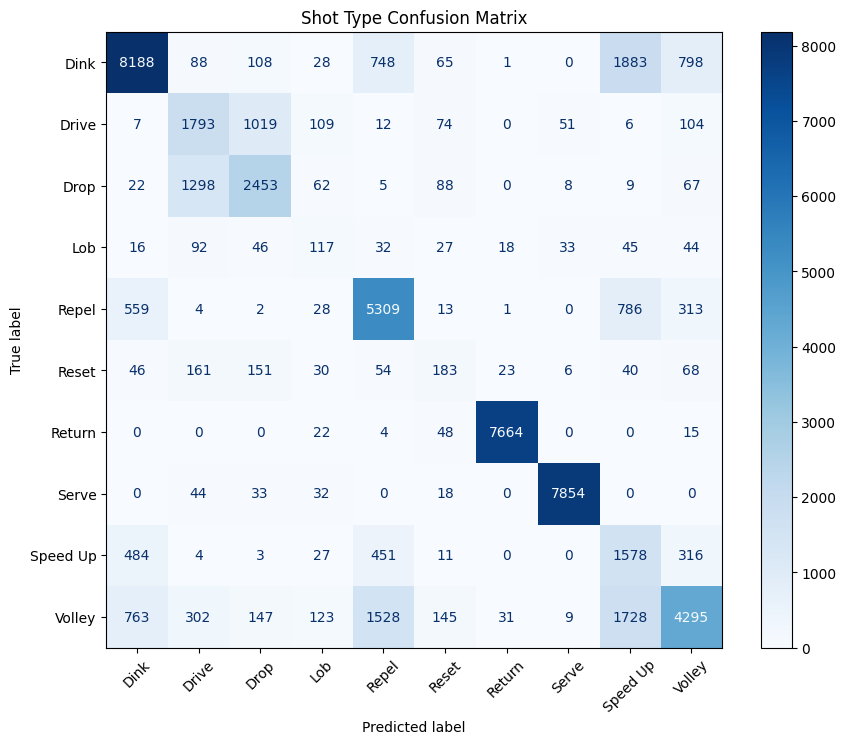

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val_encoded, y_pred_val)
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Shot Type Confusion Matrix')
plt.show()

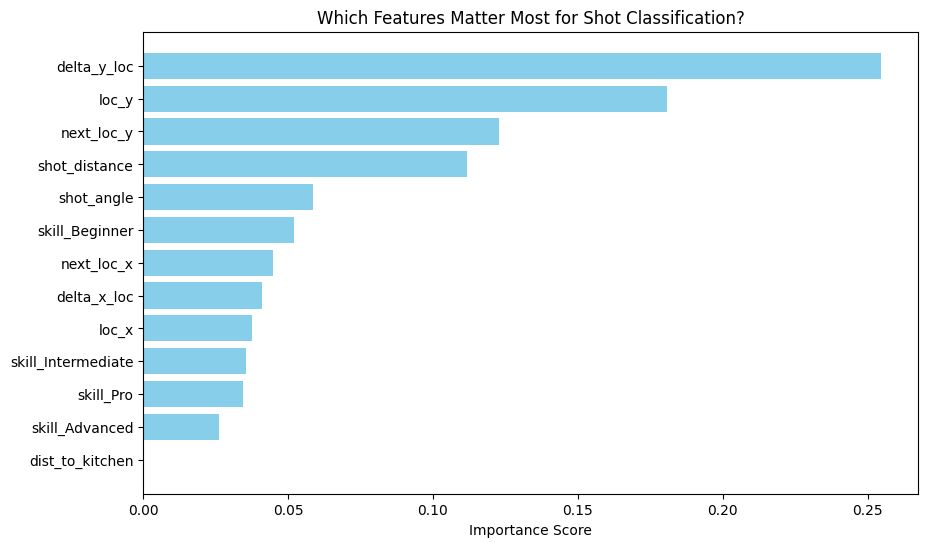

In [ ]:
# Get feature importance
importances = grid_search.best_estimator_.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Which Features Matter Most for Shot Classification?')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# now to run predicitons on the test set to see if the results are still good
y_pred_test = best_xgb.predict(X_test_scaled)

In [ ]:
# Use the encoded (numeric) ground truth to match the numeric predictions
target_names = encoder.classes_

print(classification_report(
    y_test_encoded,   # Use the encoded version!
    y_pred_test,
    target_names=target_names
))

              precision    recall  f1-score   support

        Dink       0.81      0.69      0.74     11907
       Drive       0.47      0.57      0.52      3175
        Drop       0.63      0.60      0.62      4013
         Lob       0.22      0.27      0.24       470
       Repel       0.65      0.76      0.70      7015
       Reset       0.27      0.25      0.26       762
      Return       0.99      0.99      0.99      7753
       Serve       0.98      0.98      0.98      7981
    Speed Up       0.25      0.54      0.34      2873
      Volley       0.72      0.47      0.57      9071

    accuracy                           0.72     55020
   macro avg       0.60      0.61      0.60     55020
weighted avg       0.75      0.72      0.72     55020



### Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from collections import Counter

In [ ]:
rf_class = RandomForestClassifier()

grid_params = {'class_weight':['balanced', None],
               'n_estimators':[6, 7, 8],
               'criterion':['gini', 'entropy'],
               'max_depth':[3, 4, 5]}

skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

gridsearch_rf = GridSearchCV(rf_class,
                             grid_params,
                             scoring='f1_micro',
                             return_train_score=True,
                             cv=skf)

In [ ]:
gridsearch_rf.fit(X_train_scaled, y_train_encoded)
rf_model = gridsearch_rf.best_estimator_
print(rf_model)
print(gridsearch_rf.best_score_)

RandomForestClassifier(criterion='entropy', max_depth=5, n_estimators=8)
0.6880713980404604


In [ ]:
# scores perfectly on test set
y_predicted = rf_model.predict(X_test_scaled)
confusion_matrix(y_test, y_predicted)

NameError: name 'confusion_matrix' is not defined

Now we can finally apply our best xgboost model to the data with missing shot_type labels.

In [ ]:
# after evaluate, apply to X_predict_scaled
predict_df['predicted_type'] = best_xgb.predict(X_predict_scaled)
predict_df['predicted_type'] = encoder.inverse_transform(predict_df['predicted_type'])

In [ ]:
predict_df.head()

Now to fill in the predicted values for shot type into the locations where it was previously tzApp

In [ ]:
clean_mdl_data['final_shot_type'] = clean_mdl_data['shot_type_bins']
clean_mdl_data.loc[predict_df.index, 'final_shot_type'] = predict_df['predicted_type']

In [ ]:
tzapp_df = clean_mdl_data[clean_mdl_data['shot_type'] == 'tzApp']
tzapp_df.head()

In [ ]:
clean_mdl_data['final_shot_type'].value_counts()

#### Figuring out Unknown Shots

In [ ]:
unknown_shots = new_df[new_df['shot_type'] == 'U']
unknown_shots.head()

In [ ]:
sns.boxplot(x='shot_type', y='shot_distance', data=unknown_shots)

In [ ]:
sns.histplot(data=unknown_shots, x='shot_distance')

In [ ]:
sns.histplot(data=unknown_shots, x='next_loc_y')

In [ ]:
sns.histplot(data=unknown_shots, x='dist_to_kitchen')

In [ ]:
sns.scatterplot(data=unknown_shots, x='shot_distance', y='dist_to_kitchen')

In [ ]:
sns.scatterplot(data=unknown_shots, x='dist_to_kitchen', y='next_loc_y')

In [ ]:
sns.histplot(data=unknown_shots, x='loc_x')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_pickleball_court(df):
    fig, ax = plt.subplots(figsize=(6,8))

    # Dimensions based on standard pickleball court (20' x 44')
    width = 20
    half_length = 22
    kitchen_offset = 7

    # 1. Draw the Main Court Boundary
    court = patches.Rectangle((0, -half_length), width, half_length * 2,
                              linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(court)

    # 2. Draw the Net (Center line at y=0)
    ax.plot([0, width], [0, 0], color='black', linewidth=3, label='Net')

    # 3. Draw Non-Volley Zone (Kitchen) lines
    ax.plot([0, width], [kitchen_offset, kitchen_offset], color='black', linewidth=2)
    ax.plot([0, width], [-kitchen_offset, -kitchen_offset], color='black', linewidth=2)

    # 4. Draw Center lines (splitting the service courts)
    ax.plot([width/2, width/2], [kitchen_offset, half_length], color='black', linewidth=2)
    ax.plot([width/2, width/2], [-kitchen_offset, -half_length], color='black', linewidth=2)

    # 5. Highlight the Kitchen Area
    kitchen_top = patches.Rectangle((0, 0), width, kitchen_offset, color='gray', alpha=0.1)
    kitchen_bottom = patches.Rectangle((0, -kitchen_offset), width, kitchen_offset, color='gray', alpha=0.1)
    ax.add_patch(kitchen_top)
    ax.add_patch(kitchen_bottom)

    # Plot Start Locations (loc_x, loc_y)
    ax.scatter(df['loc_x'], df['loc_y'], color='blue', alpha=0.5, s=60,
               label='Shot Start (loc_x, loc_y)', zorder=3)

    # Plot End Locations (next_loc_x, next_loc_y)
    ax.scatter(df['next_loc_x'], df['next_loc_y'], color='red', alpha=0.5, s=60,
               label='Shot End (next_loc_x, next_loc_y)', zorder=3)

    # Formatting
    ax.set_xlim(-2, width + 2)
    ax.set_ylim(-half_length - 2, half_length + 2)
    ax.set_aspect('equal')
    ax.set_title("Pickleball Shot Map: Start vs End Locations")
    ax.set_xlabel("Width (0 to 20)")
    ax.set_ylabel("Length (-22 to 22)")
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# To use with your dataframe:
# draw_pickleball_court(unknown_shots)

In [ ]:
draw_pickleball_court(unknown_shots[500:600])

This seems like a limitation to our analysis as there is no structure to how unknown shots are distributed and how we may be able to categorize them.

Similar to how we worked with tzApp shot type, we will be doing the same KNN approach with unknown shot types to help categorize them but also keep with the minimum number of shot types to help us with the model data.

In [ ]:
# 2. Split into Training (Knowns) and Prediction (U)
train_df = clean_mdl_data.copy()
train_df = train_df[train_df['shot_type'] != 'U']
predict_df = new_df[new_df['shot_type'] == 'U']

X_train = train_df[features]
y_train = train_df['final_shot_type']
X_predict = predict_df[features]

# 3. Scale the data (Mandatory for KNN!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_predict_scaled = scaler.transform(X_predict)

# 4. Train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5) # 5 is a good baseline
knn.fit(X_train_scaled, y_train)

# 5. Categorize the tz_App shots
predict_df['predicted_type'] = knn.predict(X_predict_scaled)

# See the results!
print(predict_df['predicted_type'].value_counts())

In [ ]:
clean_mdl_data.loc[predict_df.index, 'final_shot_type'] = predict_df['predicted_type']

In [ ]:
u_df = clean_mdl_data[clean_mdl_data['shot_type'] == 'U']
u_df.head()

Now let's check the value counts from the final_shot_types to see if it is finally in the shape that we want for modeling

In [ ]:
clean_mdl_data['final_shot_type'].value_counts()

### Cleaning up Other and Ball Shot Types

In [ ]:
ball_df = clean_mdl_data[clean_mdl_data['shot_type'] == 'ball']
focused_ball = ball_df[['srv_team_id','w_team_id','rally_len','shot_nbr','shot_distance','shot_angle','srv_point_won']]
focused_ball.head(6)

In [ ]:
# 1. Identify rallies that contain a 'ball' shot
rallies_with_ball = clean_mdl_data[clean_mdl_data['shot_type'] == 'ball']['rally_id'].unique()

# 2. Filter, sort, and group to create the list of lists
rally_sequences = (
    clean_mdl_data[clean_mdl_data['rally_id'].isin(rallies_with_ball)]
    .sort_values(['rally_id', 'shot_nbr'])
    .groupby('rally_id')['final_shot_type']
    .apply(list)
    .tolist()
)

# 3. Take a peek at the first 3 rallies
for i, sequence in enumerate(rally_sequences[:]):
    print(f"Rally {i+1}: {sequence}")

In [ ]:
# 2. Split into Training (Knowns) and Prediction (U)
train_df = clean_mdl_data.copy()
train_df = train_df[train_df['shot_type'] != 'ball']
predict_df = new_df[new_df['shot_type'] == 'ball']

X_train = train_df[features]
y_train = train_df['final_shot_type']
X_predict = predict_df[features]

# 3. Scale the data (Mandatory for KNN!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_predict_scaled = scaler.transform(X_predict)

# 4. Train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5) # 5 is a good baseline
knn.fit(X_train_scaled, y_train)

# 5. Categorize the tz_App shots
predict_df['predicted_type'] = knn.predict(X_predict_scaled)

# See the results!
print(predict_df['predicted_type'].value_counts())

In [ ]:
clean_mdl_data.loc[predict_df.index, 'final_shot_type'] = predict_df['predicted_type']

In [ ]:
other_df = clean_mdl_data[clean_mdl_data['shot_type'] == 'O']
focused_other = other_df[['srv_team_id','w_team_id','rally_len','shot_nbr','shot_distance','shot_angle','dist_to_kitchen','srv_point_won']]
focused_other.head(12)

In [ ]:
# 1. Identify rallies that contain a 'ball' shot
rallies_with_other= clean_mdl_data[clean_mdl_data['shot_type'] == 'O']['rally_id'].unique()

# 2. Filter, sort, and group to create the list of lists
rally_sequences = (
    clean_mdl_data[clean_mdl_data['rally_id'].isin(rallies_with_other)]
    .sort_values(['rally_id', 'shot_nbr'])
    .groupby('rally_id')['final_shot_type']
    .apply(list)
    .tolist()
)

# 3. Take a peek at the first 3 rallies
for i, sequence in enumerate(rally_sequences[:]):
    print(f"Rally {i+1}: {sequence}")

In [ ]:
# 2. Split into Training (Knowns) and Prediction (U)
train_df = clean_mdl_data.copy()
train_df = train_df[train_df['shot_type'] != 'O']
predict_df = new_df[new_df['shot_type'] == 'O']

X_train = train_df[features]
y_train = train_df['final_shot_type']
X_predict = predict_df[features]

# 3. Scale the data (Mandatory for KNN!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_predict_scaled = scaler.transform(X_predict)

# 4. Train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5) # 5 is a good baseline
knn.fit(X_train_scaled, y_train)

# 5. Categorize the tz_App shots
predict_df['predicted_type'] = knn.predict(X_predict_scaled)

# See the results!
print(predict_df['predicted_type'].value_counts())

In [ ]:
clean_mdl_data.loc[predict_df.index, 'final_shot_type'] = predict_df['predicted_type']

In [ ]:
clean_mdl_data['final_shot_type'].value_counts(normalize=True)

## The Final Data Frame

In this step we will be removing all unecessary columns for our final dataset. This will make sure that our data is focused for the task that we wish to accomplish.

In [ ]:
clean_mdl_data.info()

In [ ]:
keep_cols = ['rally_id','rally_nbr','rally_len','shot_nbr', 'loc_x', 'loc_y', 'next_loc_x', 'next_loc_y', 'delta_x_loc', 'delta_y_loc', 'shot_distance', 'shot_angle', 'srv_point_won',
             'skill_lvl', 'team_hitting', 'next_loc_x_missing','final_shot_type']
final_clean_ml_df = clean_mdl_data[keep_cols]

In [ ]:
# As all of the missing value flags occur due to the end of a rally, we can combine them to just great a generic missing value flag
final_clean_ml_df = final_clean_ml_df.rename(columns={'next_loc_x_missing': 'missing_value_flag'})

In [ ]:
final_clean_ml_df['skill_lvl'].value_counts()

In [ ]:
final_clean_ml_df.head()

In [ ]:
final_clean_ml_df.shape

#### Saving the Modeling Data

In [ ]:
final_clean_ml_df.to_csv('/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/processed/clean_mdl_data.csv')